### Run accuracy validation for given prompts on different models

In [ ]:
from pathlib import Path
import sys
import json
import os

IN_GITHUB = os.getenv("GITHUB_ACTIONS") == "true"
try:
    import google.colab

    IN_COLAB = True
    print("Running as a Colab notebook")
except:
  IN_COLAB = False
  print("Not running as a Colab notebook")

if IN_COLAB:
  !pip install transformer_lens
  !pip install Levenshtein
  !pip install anthropic
  from google.colab import drive
  drive.mount('/content/drive')
  ! pwd # Returns /content
  ! cp "/content/drive/MyDrive/Colab Notebooks/temporal_scope_to_check_accuracy.json" /content/temporal_scope_to_check_accuracy.json
  ! cp "/content/drive/MyDrive/Colab Notebooks/.env.example" /content/.env.example
  from dotenv import load_dotenv
  load_dotenv(".env.example")

Running as a Colab notebook
  Using cached anthropic-0.84.0-py3-none-any.whl.metadata (3.0 kB)
Using cached anthropic-0.84.0-py3-none-any.whl (455 kB)
Mounted at /content/drive
/content


1. Read the dataset, prepare inputs

In [ ]:
temporal_dataset = None
dataset_path = "temporal_scope_to_check_accuracy.json"
with open(dataset_path) as f:
    temporal_dataset = json.load(f)

prompts = []
correct_answers = []
incorrect_answers = []

for sample in temporal_dataset:
    clean_question = sample["clean"]["question"]
    prompts.append(clean_question)
    correct_answers.append(sample["clean"]["answer"])
    incorrect_answers.append(sample["corrupted"]["answer"])

    corrupted_question = sample["corrupted"]["question"]
    prompts.append(corrupted_question)
    correct_answers.append(sample["corrupted"]["answer"])
    incorrect_answers.append(sample["clean"]["answer"])

In [ ]:
models = ["gpt2", "gpt2-medium", "gpt2-large", "gpt2-xl"]

In [ ]:
# Expected results of validation:
# - Full model accuracy: can model accurately recognize that question implies short/long-time horizons?
# - Label prediction: can model correctly predict that next token after a prompt will be ' short' or ' long' horizon marker? (Also checks the model's conformance to a format)

In [ ]:
# Additional AI-powered validation of the model's answer:
validation_prompt = """You are validating the correctness of LLM's answer to the following question.
Question: \"{question}\"
You need to study the generated text of the model to understand which time horizon the model has chosen as an answer to the question: short-term or long-term.
Please be aware that input prompt (or question) is prepended to the generated text of the model, so the model's output will contain it.
Model's output: \"{model_output}\"
After identification of model's answer to the question in the sense of short-term or long-term horizons, please compare its answer to the expected answer \"{expected_answer}\".
Do answers match?
"""
validation_response_format = {
  "format": {
      "type": "json_schema",
      "schema": {
          "type": "object",
          "properties": {
          "is_correct": {
              "type": "boolean",
              "description": "True if answers match, False if not"
              }
          },
          "required": ["is_correct"],
          "additionalProperties": False
      }
  }
}

import anthropic

def ask_claude_for_correctness(question, model_output, expected_answer):
    try:
        client = anthropic.Anthropic()

        response = client.messages.create(
            model="claude-opus-4-6",
            max_tokens=1024,
            messages=[
                {
                    "role": "user",
                    "content": validation_prompt.format(question=question, model_output=model_output, expected_answer=expected_answer),
                }
            ],
            output_config=validation_response_format
        )
        json_object = json.loads(response.content[0].text)
        return json_object["is_correct"]
    except Exception as e:
        return f"Error quering the Claude-Opus-4.6: {str(e)}"

# Commented debug line:
ask_claude_for_correctness("The goal is to make a cappuchino. It is a short-term or long-term goal? The answer is:",
                           "The goal is to make a cappuchino. It is a short-term or long-term goal? The answer is:short-term goal",
                          " short")

True

In [ ]:
from transformer_lens import (
    HookedTransformer
)
import torch
import Levenshtein
import anthropic
import json
import numpy as np
import gc


first_tokens_accuracy_for_models = {}
classification_accuracy_for_models = {}
logits_diff_for_models = {}
probs_diff_for_models = {}


for model_name in models:
  gc.collect()
  # Create a model
  model = HookedTransformer.from_pretrained(model_name)

  # Tokenize prompts
  all_prompts_tokens = []
  for prompt in prompts:
    tokens = model.to_tokens(prompt)
    all_prompts_tokens.append(tokens)
  # Some verbose for visual validation of results
  for i in range(len(prompts)):
    string_tokens = [f"{i}, {model.to_string(t)}" for i, t in enumerate(all_prompts_tokens[i][0])]
    print(string_tokens)

  # Correct classifications to short or long horizons:
  correct_classifications = 0
  # Correct classifications of expected next token predictions:
  # It measures complex phenomena: correct guessing of time horizon and model's conformance to the asked format.
  correct_first_tokens = 0

  correct_answer_logits = []
  correct_answer_probs = []
  incorrect_answer_logits = []
  incorrect_answer_probs = []

  # Also variables for extra verbosing
  top3_tokens = []
  top3_logits = []
  for index, prompt_tokens in enumerate(all_prompts_tokens):
    logits, cache = model.run_with_cache(prompt_tokens)
    del cache
    gc.collect()

    # Only for verbosing purpose:
    sorted_logits = torch.sort(logits[-1, -1, :], descending=True)
    top3_tokens.append(sorted_logits.indices[0:3].cpu().detach())
    top3_logits.append(sorted_logits.values[0:3].cpu().detach().numpy())

    # Measuring short <-> long separability.
    # short <-> long distance calculation in raw logits and probabilities of
    # logits after applying the softmax
    correct_answer = correct_answers[index]
    incorrect_answer = incorrect_answers[index]

    correct_token = model.to_single_token(correct_answers[index])
    incorrect_token = model.to_single_token(incorrect_answers[index])

    correct_answer_logits.append(logits[-1, -1, correct_token].cpu().detach().numpy())
    incorrect_answer_logits.append(logits[-1, -1, incorrect_token].cpu().detach().numpy())

    log_probs = torch.nn.functional.softmax(logits[-1, -1, :], dim=-1)
    correct_answer_probs.append(log_probs[correct_token].cpu().detach().numpy())
    incorrect_answer_probs.append(log_probs[incorrect_token].cpu().detach().numpy())

    # Accuracy of labels prediction: accuracy of next-token prediction to be exactly the label we want.
    # Accuracy of complex phenomena: correct guessing of time horizon and model's conformance to the asked format.
    first_token = model.to_string(top3_tokens[index][0])
    correctness_ratio = Levenshtein.ratio(first_token, correct_answers[index])
    if correctness_ratio > 0.9:
      correct_first_tokens += 1
    print(f"\n\nFor prompt: {prompts[index]}:\n")
    print(f"First token: {first_token}, correct answer: {correct_answer}, similarity: {correctness_ratio}")

    # Accuracy of classification to short/long based on model's output context
    resulted_text = model.generate(prompt_tokens, max_new_tokens=150, do_sample=False, return_type='str', verbose=False)
    print(f"Resulted text: {resulted_text}")
    is_classification_correct = ask_claude_for_correctness(prompts[index], resulted_text, correct_answer)
    print(f"Classification is correct: {is_classification_correct}")
    correct_classifications += int(is_classification_correct)


    del logits
    del sorted_logits
    gc.collect()
  print(f"For model {model_name}: top-3 tokens = {model.to_string(torch.stack(top3_tokens))}")
  print(f"For model {model_name}: top-3 logits = {top3_logits}")
  print(f"For model {model_name}: correct first tokens = {correct_first_tokens}")
  print(f"For model {model_name}: correct classifications = {correct_classifications}")
  print(f"For model {model_name}: First token accuracy = {float(correct_first_tokens)/len(all_prompts_tokens)}")
  print(f"For model {model_name}: Classification accuracy = {float(correct_classifications)/len(all_prompts_tokens)}")
  print(f"For model {model_name}: correct answer logits = {correct_answer_logits}")
  print(f"For model {model_name}: incorrect answer logits = {incorrect_answer_logits}")
  print(f"For model {model_name}: correct answer probs = {correct_answer_probs}")
  print(f"For model {model_name}: incorrect answer probs = {incorrect_answer_probs}")

  first_tokens_accuracy_for_models[model_name] = float(correct_first_tokens)/len(all_prompts_tokens)
  classification_accuracy_for_models[model_name] = float(correct_classifications)/len(all_prompts_tokens)
  logits_diff_for_models[model_name] = np.abs(np.array(correct_answer_logits) - np.array(incorrect_answer_logits)).mean()
  probs_diff_for_models[model_name] = np.abs(np.array(correct_answer_probs) - np.array(incorrect_answer_probs)).mean()
  del top3_tokens

  print(f"First tokens accuracy for models: {first_tokens_accuracy_for_models}")
  print(f"Classification accuracy for models: {classification_accuracy_for_models}")
  print(f"Logits diff for models: {logits_diff_for_models}")
  print(f"Probs diff for models: {probs_diff_for_models}")
  del top3_logits
  del all_prompts_tokens
  del model

  gc.collect()


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-xl into HookedTransformer
['0, <|endoftext|>', '1, The', '2,  goal', '3,  is', '4,  to', '5,  make', '6,  one', '7,  cup', '8,  of', '9,  coffee', '10, .', '11,  Is', '12,  this', '13,  a', '14,  short', '15, -', '16, term', '17,  or', '18,  long', '19, -', '20, term', '21,  goal', '22, ?', '23,  The', '24,  answer', '25,  is', '26, :']
['0, <|endoftext|>', '1, The', '2,  goal', '3,  is', '4,  to', '5,  master', '6,  the', '7,  craft', '8,  of', '9,  specialty', '10,  coffee', '11,  ro', '12, asting', '13, .', '14,  Is', '15,  this', '16,  a', '17,  short', '18, -', '19, term', '20,  or', '21,  long', '22, -', '23, term', '24,  goal', '25, ?', '26,  The', '27,  answer', '28,  is', '29, :']
['0, <|endoftext|>', '1, The', '2,  goal', '3,  is', '4,  to', '5,  take', '6,  a', '7,  ten', '8, -', '9, minute', '10,  walk', '11, .', '12,  Is', '13,  this', '14,  a', '15,  short', '16, -', '17, term', '18,  or', '19,  long', '20, -', '21, term', '22,  goal', '23, ?'

,Correct first tokens accuracy
gpt2,0.000000
gpt2-medium,0.348101
gpt2-large,0.240506
gpt2-xl,0.006329


,Correct classification accuracy
gpt2,0.006329
gpt2-medium,0.348101
gpt2-large,0.284810
gpt2-xl,0.082278


(0.0, 1.0)

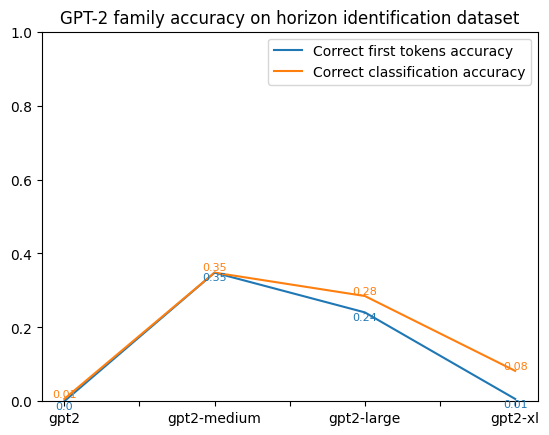

In [ ]:
import pandas as pd

gpt2_ft_acc_df = pd.DataFrame(first_tokens_accuracy_for_models.values(), first_tokens_accuracy_for_models.keys(), columns=["Correct first tokens accuracy"])
display(gpt2_ft_acc_df)
gpt2_acc_df = pd.DataFrame(classification_accuracy_for_models.values(), classification_accuracy_for_models.keys(), columns=["Correct classification accuracy"])
display(gpt2_acc_df)

import matplotlib.pyplot as plt
%matplotlib inline
ax = gpt2_ft_acc_df.plot(title="GPT-2 family accuracy on horizon identification dataset")
gpt2_acc_df.plot(title="GPT-2 family accuracy on horizon identification dataset", ax=ax)
for index in range(len(first_tokens_accuracy_for_models.keys())):
    ax.text(index, gpt2_ft_acc_df.iloc[index, 0], round(gpt2_ft_acc_df.iloc[index, 0], 2), verticalalignment='top', ha='center', size=8, color='tab:blue', in_layout=True)
    ax.text(index, gpt2_acc_df.iloc[index, 0], round(gpt2_acc_df.iloc[index, 0], 2), verticalalignment='bottom', ha='center', size=8, color='tab:orange', in_layout=True)
plt.ylim(0, 1)